In [9]:
! pip install torch torchvision numpy matplotlib opencv-python  

In [10]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
from sklearn.cluster import KMeans
import glob

!curl -L -o pca_face_images.zip "https://www.dropbox.com/s/0g15mi9czdbcqfy/pca_face_images.zip?dl=1"
!unzip -o -q pca_face_images.zip -d data
!rm pca_face_images.zip

data_path = 'data/pca_face_images/'
image_files = sorted(glob.glob(os.path.join(data_path, '**/*.[pP][gG][mM]'), recursive=True) + 
                     glob.glob(os.path.join(data_path, '**/*.[pP][nN][gG]'), recursive=True) +
                     glob.glob(os.path.join(data_path, '**/*.[jJ][pP][gG]'), recursive=True))

image_files = [f for f in image_files if '__MACOSX' not in f and not os.path.basename(f).startswith('.')]

if not image_files:
    raise FileNotFoundError(f"No images found in {data_path}")

print(f"Found {len(image_files)} images.")

sample_img = cv2.imread(image_files[0], cv2.IMREAD_GRAYSCALE)
h, w = sample_img.shape
d = h * w
N = len(image_files)
print(f"Image dimensions: {h}x{w} (d={d})")

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   136  100   136    0     0    616      0 --:--:-- --:--:-- --:--:--   618
100    17  100    17    0     0     20      0 --:--:-- --:--:-- --:--:--    20
100   496    0   496    0     0    390      0 --:--:--  0:00:01 --:--:--  2818
100 4130k  100 4130k    0     0  2586k      0  0:00:01  0:00:01 --:--:-- 2586k
Found 110 images.
Image dimensions: 243x320 (d=77760)


Zero mean vectors

In [11]:
X_raw = np.zeros((d, N))
for i, f in enumerate(image_files):
    img = cv2.imread(f, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (w, h))
    X_raw[:, i] = img.flatten()


mean_image = np.mean(X_raw, axis=1, keepdims=True)
X_zero_mean = X_raw - mean_image
print(X_zero_mean.shape) # too large thus will use X^TX's eigenvalues for PC
K = np.dot(X_zero_mean.T, X_zero_mean) / (N - 1)

(77760, 110)


PCA and Eigenvectores

In [12]:

evals_small, V_small = np.linalg.eigh(K)
idx = evals_small.argsort()[::-1]
eigenvalues = evals_small[idx]
V = V_small[:, idx]
eigenvectors = np.dot(X_zero_mean, V)
norms = np.linalg.norm(eigenvectors, axis=0)
norms[norms < 1e-10] = 1.0
eigenvectors = eigenvectors / norms


Important eigenvalues which capture most of the variance (considering the cumulative explained variance threshold 80%)

Number of components to explain 80% variance: 8


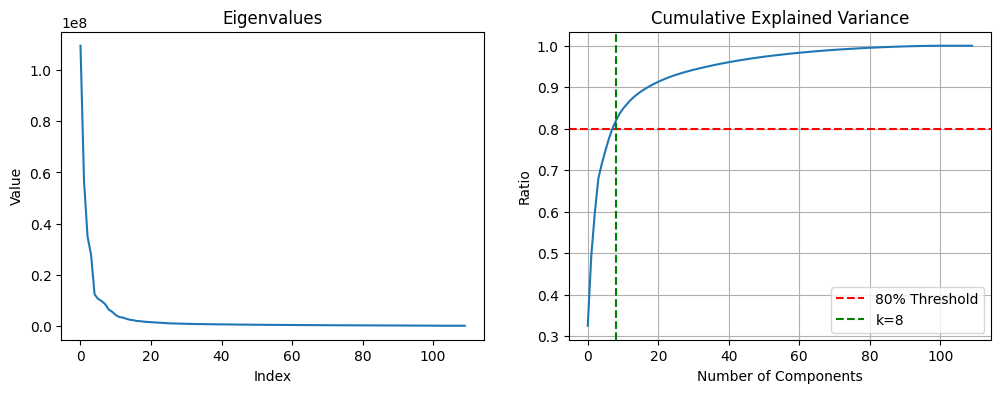

In [13]:
pos_evals = np.maximum(eigenvalues, 0)
cumulative_variance = np.cumsum(pos_evals) / np.sum(pos_evals)
k_80 = int(np.argmax(cumulative_variance >= 0.80) + 1)
print(f"Number of components to explain 80% variance: {k_80}")

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(eigenvalues)
plt.title("Eigenvalues")
plt.xlabel("Index")
plt.ylabel("Value")

plt.subplot(1, 2, 2)
plt.plot(cumulative_variance)
plt.axhline(y=0.80, color='r', linestyle='--', label='80% Threshold')
plt.axvline(x=k_80, color='g', linestyle='--', label=f'k={k_80}')
plt.title("Cumulative Explained Variance")
plt.xlabel("Number of Components")
plt.ylabel("Ratio")
plt.legend()
plt.grid(True)
plt.show()

We can plan to retain these eigenvalues which explain ~80% of the variance 

Reconstruction error with these 8 components

Reconstruction with k=8 components which cumulatively explain 80% Variance
Mean Squared Error: 854.8413


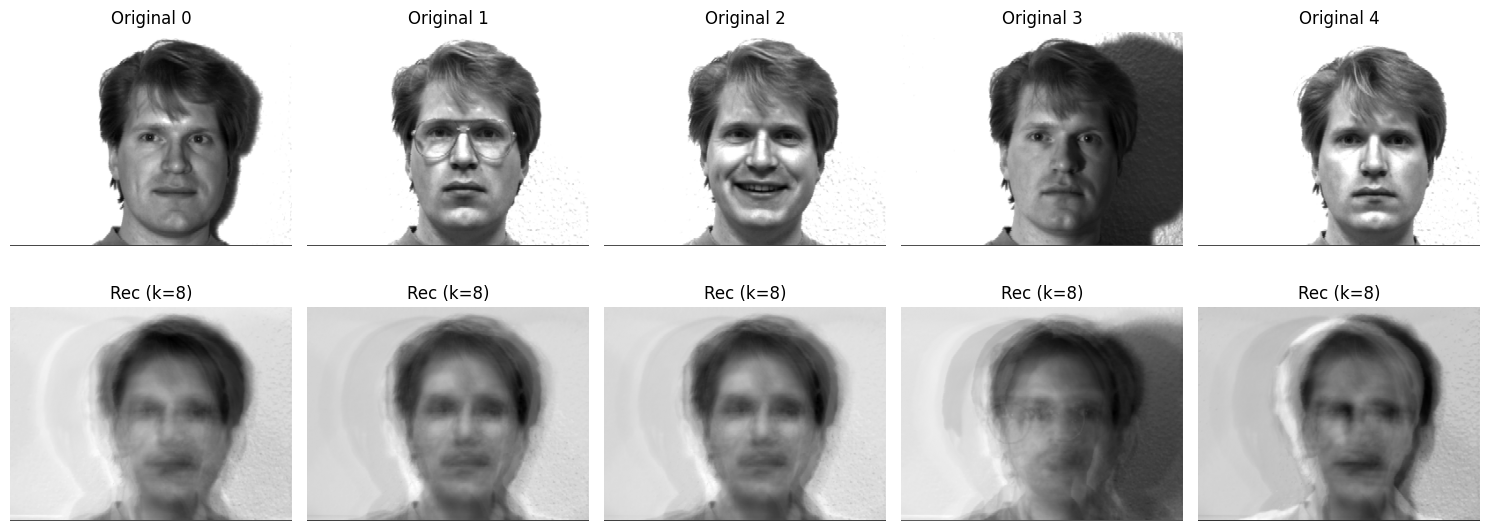

In [14]:
def reconstruct_images(X, eigenvectors, mean_image, num_components):
    U_k = eigenvectors[:, :num_components]
    weights = np.dot(U_k.T, X)
    X_rec = np.dot(U_k, weights) + mean_image
    return X_rec, weights

X_reconstructed, weights_k80 = reconstruct_images(X_zero_mean, eigenvectors, mean_image, k_80)
mse = np.mean((X_raw - X_reconstructed)**2)
print(f"Reconstruction with k={k_80} components which cumulatively explain 80% Variance")
print(f"Mean Squared Error: {mse:.4f}")

n_samples = 5
plt.figure(figsize=(15, 6))
for i in range(n_samples):
    plt.subplot(2, n_samples, i + 1)
    plt.imshow(X_raw[:, i].reshape(h, w), cmap='gray')
    plt.title(f"Original {i}")
    plt.axis('off')
    
    plt.subplot(2, n_samples, i + 1 + n_samples)
    plt.imshow(X_reconstructed[:, i].reshape(h, w), cmap='gray')
    plt.title(f"Rec (k={k_80})")
    plt.axis('off')
plt.tight_layout()
plt.show()

Reconstruction error with different values of K

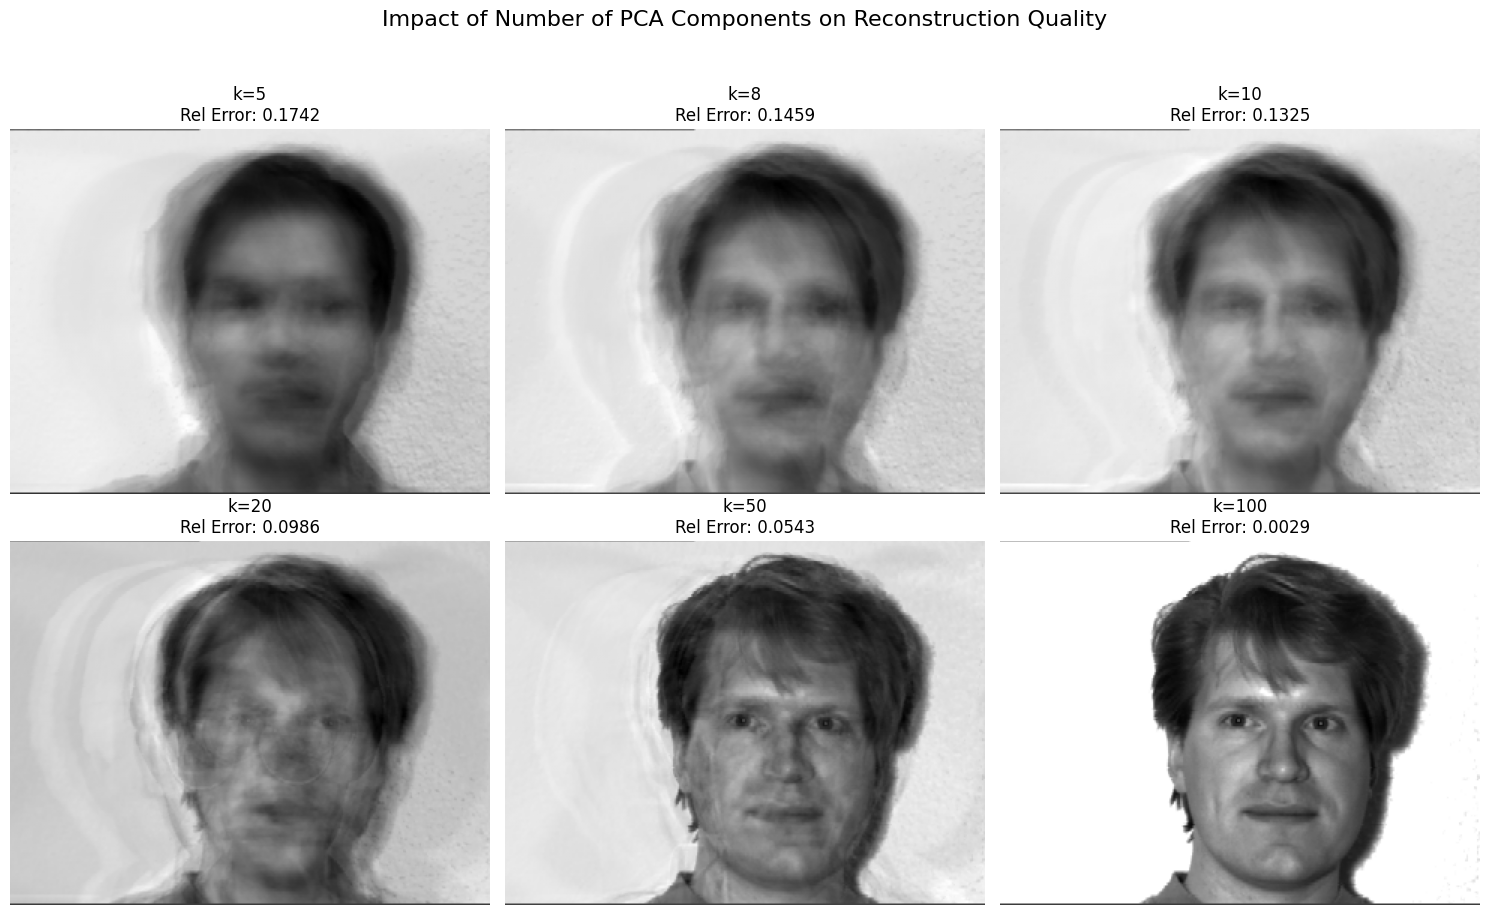

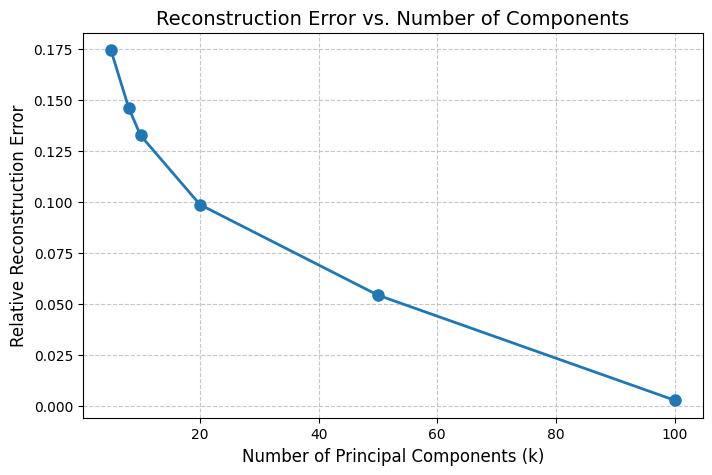

In [15]:
k_values = sorted([5, 10, 20, 50, k_80, 100])
errors = []

plt.figure(figsize=(15, 10))
for i, k in enumerate(k_values):
    X_rec, _ = reconstruct_images(X_zero_mean, eigenvectors, mean_image, k)
    err = np.linalg.norm(X_raw - X_rec, 'fro') / np.linalg.norm(X_raw, 'fro')
    errors.append(err)
    plt.subplot(2, 3, i + 1)
    plt.imshow(X_rec[:, 0].reshape(h, w), cmap='gray')
    plt.title(f"k={k}\nRel Error: {err:.4f}")
    plt.axis('off')

plt.suptitle("Impact of Number of PCA Components on Reconstruction Quality", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(k_values, errors, 'o-', linewidth=2, markersize=8)
plt.xlabel("Number of Principal Components (k)", fontsize=12)
plt.ylabel("Relative Reconstruction Error", fontsize=12)
plt.title("Reconstruction Error vs. Number of Components", fontsize=14)
plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.show()

As expected, increasing the number of components used in reconstruction leads to a lower reconstruction error however, we can achieve a decent reconstruction with a few components.

In [16]:
from collections import Counter

labels = []
for f in image_files:
    subject = os.path.basename(os.path.dirname(f))
    if subject == 'pca_face_images' or subject == 'data':
        subject = os.path.basename(f).split('_')[0]
    labels.append(subject)

unique_labels = sorted(list(set(labels)))
n_subjects = len(unique_labels)
print(f"Actual number of individuals: {n_subjects}\n")

kmeans = KMeans(n_clusters=n_subjects, random_state=42, n_init=10)
cluster_assignments = kmeans.fit_predict(weights_k80.T)

total_correct = 0
for c in range(n_subjects):
    members = [labels[i] for i in range(len(labels)) if cluster_assignments[i] == c]
    counts = Counter(members)
    majority = counts.most_common(1)[0][1]
    total_correct += majority
    print(f"Cluster {c}: {dict(counts)}")

accuracy = total_correct / len(labels)
print(f"\nClustering accuracy for images of same person: {accuracy:.2%}")

Actual number of individuals: 10

Cluster 0: {'subject01': 9}
Cluster 1: {'subject06': 9}
Cluster 2: {'subject03': 7, 'subject07': 8, 'subject08': 2, 'subject09': 1}
Cluster 3: {'subject01': 1, 'subject02': 1, 'subject03': 1, 'subject04': 1, 'subject05': 1, 'subject06': 1, 'subject07': 1, 'subject08': 1, 'subject09': 1, 'subject10': 1}
Cluster 4: {'subject01': 1, 'subject03': 1, 'subject04': 1, 'subject05': 1, 'subject07': 1, 'subject08': 1, 'subject09': 1}
Cluster 5: {'subject07': 1, 'subject08': 2, 'subject10': 7}
Cluster 6: {'subject02': 10, 'subject04': 9}
Cluster 7: {'subject05': 9}
Cluster 8: {'subject06': 1, 'subject08': 3, 'subject09': 7}
Cluster 9: {'subject03': 2, 'subject08': 2, 'subject09': 1, 'subject10': 3}

Clustering accuracy for images of same person: 58.18%
